# 파서학개론

## PDF란?

### **PDF 기본 요소**
**PDF의 가장 기본 요소 = 객체**

두 종류의 객체가 존재함.
1. 직접 객체
2. 간접 객체

**1. 직접 객체**
```
true false                       % Boolean
123 -98 34.5                     % Number
(Hello)                          % Literal string
<48656C6C6F>                     % Hexadecimal string
/Type /Catalog                   % Name object
[0 0 612 792]                    % Array
<< /Type /Page /Parent 2 0 R >>  % Dictionary
stream ... endstream             % Stream object
null                             % Null object
```

**2. 간접 객체**
```
12 0 obj ... endobj              % 간접 객체 선언
12 0 R                           % 간접 객체 호출
```

*\+ 간접 객체 식별 방법*
```
<object number> <generation number> ...
```

---

### **파일 구조**

#### **PDF = Header + Body + Cross-reference table + Trailer**

Header : 파일의 첫 줄. PDF 규격의 버전을 식별함.

Body : 간접 객체들 + 문서 요소 표현 + 객체 스트림

Cross-reference table : 간접 객체들이 파일의 어느 위치에 있는지(바이트 오프셋)에 대한 정보를 담고 있는 테이블.

Trailer : PDF 리더기가 문서의 구조를 파악하기 위해 가장 먼저 참고하는 영역.

### PDF 해석 순서

Header -> Trailer -> Xref -> Body

---

### **1] Header**
시작이 되는 부분

예시
```
%PDF-1.7
%도도
```

`%`는 PDF에서 주석을 의미. 
첫 번째 주석은 PDf 버전을 의미
두 번째 주석은 해당 파일이 바이너리 파일이라는 의미 (128 이상의 바이트를 최소 4개 이상 넣음)

---

### **2] Trailer**

**Trailer 역할**
1. Cross-reference table의 위치 제공
2. Body의 특정 특수 객체들의 위치 제공
3. 파일의 끝을 알리는 %%EOF 마커
4. 상호 참조 테이블이 시작되는 바이트 오프셋 위치(startxref)
5. 문서 계층 구조의 최상위 객체인 카탈로그 딕셔너리(Root) 정보

**Trailer 예시**
```
trailer
<<
    /Size 117
    /Root 1 0 R
    /Info 14 0 R
    /ID[
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
    ] 
>>
startxref
27593
%%EOF
```

Trailer는 PDF 파일을 수정하면 추가될 수 있다. 그런 경우 추가된 객체와 /Prev 와 /XReStm 등으로 추가 정보를 표현한다.

예시
```
trailer
<<
    /Size 117
    /Root 1 0 R
    /Info 14 0 R
    /ID[
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
    ] 
>>
startxref
27593
%%EOF

xref
0 0
trailer
<<
/Size 117
/Root 1 0 R
/Info 14 0 R
/ID[
    <9B8EA23639C1DA4FA67B9B17AEFF023D>
    <9B8EA23639C1DA4FA67B9B17AEFF023D>
] 
/Prev 27593
/XRefStm 27121
>>
startxref
30092
%%EOF
```

---

### **3] Cross-reference table**

줄여서 xref 라고 PDF에 표기함.

trailer에 존재하는 startxref가 xref의 위치를 알려줌.

xref 태그부터 trailer 태그 전까지가 모두 Cross-reference table 영역.

예시
```
xref
0 6
0000000003 65535 f
0000000017 00000 n
0000000081 00000 n
0000000000 00007 f
0000000331 00000 n
0000000409 00000 n
```

의미 해석

```
xref = cross-reference table 시작
0 6 = 0부터 시작하는 객체가 6개 있다.
0000000003 65535 f = 0번 객체
0000000017 00000 n = 1번 객체
0000000081 00000 n = 2번 객체
0000000000 00007 f = 3번 객체
0000000331 00000 n = 4번 객체
0000000409 00000 n = 5번 객체
```

**객체 사용 여부**
```
n = in-use (사용 중) | f = free (사용 안함)
```



**앞의 두 숫자의 의미**
1. n인 경우
```
0000000017 00000 n

<byte offset> <generation> n
```

해석 >> 17 바이트 위치에 해당 객체가 시작되고, 이 객체의 세대(버전)는 0번 이고, 사용되고 있는 객체이다.

2. f인 경우
```
0000000003 65535 f

<next free obj num> <generation> f
```
해석 >> 다음 free 객체의 번호는 3 이고, 더 이상 재사용 금지! (65535는 PDF generation number의 최대값)

---

### **4] Body**

기본적으로 Body는 간접 객체들의 묶음으로 보면 됨.

Header가 파일의 종류를 알려주고, Trailer와 Xref가 객체의 위치를 알려준다면, Body는 실제 내용이 들어 있는 구간임.

**Body에서 자주 만나는 객체**
1. Catalog : 문서의 시작점. Trailer의 `/Root`가 여기로 감.
2. Pages : 페이지들을 묶는 트리 노드.
3. Page : 한 장의 페이지. `/MediaBox`, `/Resources`, `/Contents`가 중요함.
4. Resources : 페이지 안에서 쓰는 글꼴, 이미지, 색상 공간 등의 이름표.
5. Stream : 압축된 데이터 덩어리. 페이지 명령어, 이미지, 폰트 파일 등이 들어감.
6. Object Stream : 여러 객체를 압축해서 한 stream 안에 넣은 형태.

#### Body 객체 확인 순서

```text
startxref
  -> xref
  -> trailer
  -> /Root
  -> Catalog
  -> /Pages
  -> Page
  -> /Resources, /Contents
```

#### 객체를 볼 때의 기준

간접 객체는 보통 다음 모양임.

```pdf
12 0 obj
<< ... >>
stream
...
endstream
endobj
```

`12 0 obj`는 객체 번호와 generation 번호임.  
`12 0 R`은 해당 객체를 참조한다는 뜻임.

---

## **(실습) PDF 해석 5단계**

### PDF 해석 1단계 (Parsing)

- Header, Body, Cross-reference Table, Trailer 분리 및 파싱

In [79]:
# PDF 선택
pdf_path = "파서학개론.pdf"

In [80]:
# PDF를 byte로 읽기
raw_pdf = None

with open(pdf_path, "rb") as f:
    raw_pdf = f.read()

# 잘 읽었는지 확인
print(raw_pdf[:20])

b'%PDF-1.7\r\n%\xb5\xb5\xb5\xb5\r\n1 0'


In [81]:
# Header 찾기. 시각화 편의를 위해 latin-1 디코딩 적용
print(raw_pdf[:17].decode('latin-1'))

%PDF-1.7
%µµµµ



**Header**
```
%PDF-1.7
%µµµµ
```

In [82]:
# 끝에 존재하는 마지막 trailer 찾기
print(raw_pdf.decode("latin-1").rindex("trailer"))

30103


In [83]:
print(raw_pdf[30103:].decode("latin-1"))

trailer
<</Size 117/Root 1 0 R/Info 14 0 R/ID[<9B8EA23639C1DA4FA67B9B17AEFF023D><9B8EA23639C1DA4FA67B9B17AEFF023D>] /Prev 27593/XRefStm 27121>>
startxref
30092
%%EOF


**Last Trailer**
```
trailer
<<
    /Size 117
    /Root 1 0 R
    /Info 14 0 R
    /ID[
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
        <9B8EA23639C1DA4FA67B9B17AEFF023D>] 
    /Prev 27593
    /XRefStm 27121
>>
startxref
30092
%%EOF
```

startxref를 통해 xref table 위치를 알 수 있음

In [84]:
print(raw_pdf[30092:30103].decode("latin-1"))

xref
0 0



**Last Xref Table**
```
xref
0 0
```
추가된 객체는 없음.

/Prev 를 통해 이전 버전이 존재함을 알 수 있음.

In [85]:
print(raw_pdf[27593:30092].decode("latin-1"))

xref
0 117
0000000015 65535 f
0000000017 00000 n
0000000168 00000 n
0000000224 00000 n
0000000508 00000 n
0000001848 00000 n
0000001984 00000 n
0000002012 00000 n
0000002175 00000 n
0000002248 00000 n
0000002494 00000 n
0000002548 00000 n
0000002602 00000 n
0000002777 00000 n
0000003024 00000 n
0000000016 65535 f
0000000017 65535 f
0000000018 65535 f
0000000019 65535 f
0000000020 65535 f
0000000021 65535 f
0000000022 65535 f
0000000023 65535 f
0000000024 65535 f
0000000025 65535 f
0000000026 65535 f
0000000027 65535 f
0000000028 65535 f
0000000029 65535 f
0000000030 65535 f
0000000031 65535 f
0000000032 65535 f
0000000033 65535 f
0000000034 65535 f
0000000035 65535 f
0000000036 65535 f
0000000037 65535 f
0000000038 65535 f
0000000039 65535 f
0000000040 65535 f
0000000041 65535 f
0000000042 65535 f
0000000043 65535 f
0000000044 65535 f
0000000045 65535 f
0000000046 65535 f
0000000047 65535 f
0000000048 65535 f
0000000049 65535 f
0000000050 65535 f
0000000051 65535 f
0000000052 65535 f
0

해당 버전에서 trailer는 다음과 같음.

In [86]:
print(raw_pdf[27593:30092].decode("latin-1").index("trailer"))

2353


In [87]:
prev_trailer = raw_pdf[27593:30092].decode("latin-1")[2353:]

print(prev_trailer)

trailer
<</Size 117/Root 1 0 R/Info 14 0 R/ID[<9B8EA23639C1DA4FA67B9B17AEFF023D><9B8EA23639C1DA4FA67B9B17AEFF023D>] >>
startxref
27593
%%EOF



**Prev Trailer**
```
trailer
<<
    /Size 117
    /Root 1 0 R
    /Info 14 0 R
    /ID[
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
        <9B8EA23639C1DA4FA67B9B17AEFF023D>
        ] 
>>
startxref
27593
%%EOF
```

해당 버전에서 xref table은 다음과 같음

In [88]:
prev_xref_table = raw_pdf[27593:30092].decode("latin-1")[:2353]
print(prev_xref_table)

xref
0 117
0000000015 65535 f
0000000017 00000 n
0000000168 00000 n
0000000224 00000 n
0000000508 00000 n
0000001848 00000 n
0000001984 00000 n
0000002012 00000 n
0000002175 00000 n
0000002248 00000 n
0000002494 00000 n
0000002548 00000 n
0000002602 00000 n
0000002777 00000 n
0000003024 00000 n
0000000016 65535 f
0000000017 65535 f
0000000018 65535 f
0000000019 65535 f
0000000020 65535 f
0000000021 65535 f
0000000022 65535 f
0000000023 65535 f
0000000024 65535 f
0000000025 65535 f
0000000026 65535 f
0000000027 65535 f
0000000028 65535 f
0000000029 65535 f
0000000030 65535 f
0000000031 65535 f
0000000032 65535 f
0000000033 65535 f
0000000034 65535 f
0000000035 65535 f
0000000036 65535 f
0000000037 65535 f
0000000038 65535 f
0000000039 65535 f
0000000040 65535 f
0000000041 65535 f
0000000042 65535 f
0000000043 65535 f
0000000044 65535 f
0000000045 65535 f
0000000046 65535 f
0000000047 65535 f
0000000048 65535 f
0000000049 65535 f
0000000050 65535 f
0000000051 65535 f
0000000052 65535 f
0

In [89]:
prev_xref_list = prev_xref_table.splitlines()
print(prev_xref_list)

['xref', '0 117', '0000000015 65535 f', '0000000017 00000 n', '0000000168 00000 n', '0000000224 00000 n', '0000000508 00000 n', '0000001848 00000 n', '0000001984 00000 n', '0000002012 00000 n', '0000002175 00000 n', '0000002248 00000 n', '0000002494 00000 n', '0000002548 00000 n', '0000002602 00000 n', '0000002777 00000 n', '0000003024 00000 n', '0000000016 65535 f', '0000000017 65535 f', '0000000018 65535 f', '0000000019 65535 f', '0000000020 65535 f', '0000000021 65535 f', '0000000022 65535 f', '0000000023 65535 f', '0000000024 65535 f', '0000000025 65535 f', '0000000026 65535 f', '0000000027 65535 f', '0000000028 65535 f', '0000000029 65535 f', '0000000030 65535 f', '0000000031 65535 f', '0000000032 65535 f', '0000000033 65535 f', '0000000034 65535 f', '0000000035 65535 f', '0000000036 65535 f', '0000000037 65535 f', '0000000038 65535 f', '0000000039 65535 f', '0000000040 65535 f', '0000000041 65535 f', '0000000042 65535 f', '0000000043 65535 f', '0000000044 65535 f', '0000000045 65

In [90]:
print(len(prev_xref_list[2:]))

117


**Prev Xref Table**
```
xref
0 117
0000000015 65535 f
0000000017 00000 n
0000000168 00000 n
0000000224 00000 n
0000000508 00000 n
0000001848 00000 n
0000001984 00000 n
0000002012 00000 n
0000002175 00000 n
0000002248 00000 n
0000002494 00000 n
0000002548 00000 n
0000002602 00000 n
0000002777 00000 n
0000003024 00000 n
0000000016 65535 f
0000000017 65535 f
...
```

해당 xref에서 객체를 추출하고 활성된 객체만 정리함.

In [91]:
# 살아있는 객체의 숫자.
print(prev_xref_table.count('n'))

21


In [92]:
# 활성화된 객체만 살림.
from pprint import pprint

alive_xref_obj = {}
i = 0

for obj in prev_xref_list[2:]:
    if 'n' in obj:
        parts = obj.split()
        alive_xref_obj[i] = {"offset": parts[0], "generation": parts[1]}
    i += 1

print(len(alive_xref_obj))
pprint(alive_xref_obj)

21
{1: {'generation': '00000', 'offset': '0000000017'},
 2: {'generation': '00000', 'offset': '0000000168'},
 3: {'generation': '00000', 'offset': '0000000224'},
 4: {'generation': '00000', 'offset': '0000000508'},
 5: {'generation': '00000', 'offset': '0000001848'},
 6: {'generation': '00000', 'offset': '0000001984'},
 7: {'generation': '00000', 'offset': '0000002012'},
 8: {'generation': '00000', 'offset': '0000002175'},
 9: {'generation': '00000', 'offset': '0000002248'},
 10: {'generation': '00000', 'offset': '0000002494'},
 11: {'generation': '00000', 'offset': '0000002548'},
 12: {'generation': '00000', 'offset': '0000002602'},
 13: {'generation': '00000', 'offset': '0000002777'},
 14: {'generation': '00000', 'offset': '0000003024'},
 110: {'generation': '00000', 'offset': '0000004961'},
 111: {'generation': '00000', 'offset': '0000005440'},
 112: {'generation': '00000', 'offset': '0000023749'},
 113: {'generation': '00000', 'offset': '0000023839'},
 114: {'generation': '00000', 

**Alive Prev Xref Table**
```
xref
0 117
0000000015 65535 f
0000000017 00000 n
0000000168 00000 n
0000000224 00000 n
0000000508 00000 n
0000001848 00000 n
0000001984 00000 n
0000002012 00000 n
0000002175 00000 n
```

In [93]:
# Trailer에서 추가 정보 확인
print(prev_trailer.replace('/', '\n/'))

trailer
<<
/Size 117
/Root 1 0 R
/Info 14 0 R
/ID[<9B8EA23639C1DA4FA67B9B17AEFF023D><9B8EA23639C1DA4FA67B9B17AEFF023D>] >>
startxref
27593
%%EOF



In [94]:
# Root와 Info 객체 확인
print(alive_xref_obj[1])

{'offset': '0000000017', 'generation': '00000'}


In [95]:
print(alive_xref_obj[14])

{'offset': '0000003024', 'generation': '00000'}


In [96]:
# Header와 Xref, Trailer를 제외한 Body 부분 추출
body = raw_pdf[17:27593]
print(body.decode("latin-1"))

1 0 obj
<</Type/Catalog/Pages 2 0 R/Lang(ko-KR) /StructTreeRoot 15 0 R/MarkInfo<</Marked true>>/Metadata 114 0 R/ViewerPreferences 115 0 R>>
endobj
2 0 obj
<</Type/Pages/Count 1/Kids[ 3 0 R] >>
endobj
3 0 obj
<</Type/Page/Parent 2 0 R/Resources<</Font<</F1 5 0 R/F2 12 0 R>>/ExtGState<</GS10 10 0 R/GS11 11 0 R>>/ProcSet[/PDF/Text/ImageB/ImageC/ImageI] >>/MediaBox[ 0 0 595.32 841.92] /Contents 4 0 R/Group<</Type/Group/S/Transparency/CS/DeviceRGB>>/Tabs/S/StructParents 0>>
endobj
4 0 obj
<</Filter/FlateDecode/Length 1265>>
stream
xµMo7ïôxtæ÷`°d;hÑ )¬" #j´iþ?:+--î.C­W>Ø°4;|v÷]~bWW·¿Þ2q}Í6·[öïz%¸è~Bð	f£åZ±`$ýø¾^}~Ï^Ö«Ín½º¼L.Û=­W]´`yÅ2ÌëÀb»¿!îÃìù?ÈÍÿÊþßëÕ+q³Ñ×_Ùî·õêÒþ±^±»[Æ2>¹_p\¸ß*±¸{A°¨åX¤\¢(yK èQà%E;Å,È¢e±º\_^qìåï/ÏìâûË/>¼Ç¦Jl]h@Ø.Ø;Ì-ytÅc'àF¬cïüÜÞa.h®Ü´uôI¡®Q8
¹0H¹kï ³ãmÙð;ðÜ¹îrø´éî þÂ²J)î=}ÙÍÌ{ÛÕèUÊó¨hØ³-Ê¥08­PP¥=ñôj¯¹Ðù²¨gfû.FË©}àC´-3ûx/C	bqÛòÈÎPäb(P$¢nÊJ6ØdSÐ
E°¿ _FPpö¿{§÷­!û	éÌ8¨;

### PDF 해석 2단계 (Decoding)

Stream 데이터를 이해할 수 있게 디코딩을 진행한다.

In [97]:
# stream object가 있는 4번 객체를 목표로 디코딩 진행.

body.decode("latin-1").index("4 0 obj")

491

In [98]:
body[491:].decode("latin-1").index("5 0 obj")

1340

In [99]:
obj4 = body[491:][:1340]
print(obj4.decode("latin-1"))

4 0 obj
<</Filter/FlateDecode/Length 1265>>
stream
xµMo7ïôxtæ÷`°d;hÑ )¬" #j´iþ?:+--î.C­W>Ø°4;|v÷]~bWW·¿Þ2q}Í6·[öïz%¸è~Bð	f£åZ±`$ýø¾^}~Ï^Ö«Ín½º¼L.Û=­W]´`yÅ2ÌëÀb»¿!îÃìù?ÈÍÿÊþßëÕ+q³Ñ×_Ùî·õêÒþ±^±»[Æ2>¹_p\¸ß*±¸{A°¨åX¤\¢(yK èQà%E;Å,È¢e±º\_^qìåï/ÏìâûË/>¼Ç¦Jl]h@Ø.Ø;Ì-ytÅc'àF¬cïüÜÞa.h®Ü´uôI¡®Q8
¹0H¹kï ³ãmÙð;ðÜ¹îrø´éî þÂ²J)î=}ÙÍÌ{ÛÕèUÊó¨hØ³-Ê¥08­PP¥=ñôj¯¹Ðù²¨gfû.FË©}àC´-3ûx/C	bqÛòÈÎPäb(P$¢nÊJ6ØdSÐ
E°¿ _FPpö¿{§÷­!û	éÌ8¨;U*æyºwKQÝÙ«¦ÒÝJ*|L'1fÉÌJ:tt_¨¬¡y	Ýõ£ tsÕ DqÐXn¬æÞfóLd°h=UêÅ¸ìÅÅî·ëaöÞË:ê ¥(P¨"Õv)è¹
HØgÃ·"Áàò$K#ìË¼7"ÃM<iÛ¥y~\0R»ÎHB}k¹PöäætØP~`Q«dH4éóE®J³ÉdR
^°ê9!ç8æ©yjªL+©2W'-á9òL¸8T?¹©8¾ßÛ©¨$<ÄCÆ.B[c0ý®^Lz ~ØWÐïyÉEL)´¡Ð·ErZl6LO ª¸1U öÓìyôÉELè\¡${&Rï"FHpDVl÷íËEhíïp½xÐí4âm)ñ®å"Å{N¯-%ÞózñÆ[-ZZMÉø<¶h:ahîtYÆA]¯Ëø!ñcWSeXIY>.ãy&\ÆÕO2Þ`åk|§¤émevï TÆ#KïT1ÆÊ¼>LýøÀK¥®-ÅTË¶p¿\Ä¤vä«ÑjYÌëj¦©U

In [100]:
stream_idx = obj4.decode("latin-1").index("stream")
endstream_idx = obj4.decode("latin-1").index("endstream")
target = obj4[stream_idx + 6: endstream_idx]
print(target.decode("latin-1"))
print(type(target))


xµMo7ïôxtæ÷`°d;hÑ )¬" #j´iþ?:+--î.C­W>Ø°4;|v÷]~bWW·¿Þ2q}Í6·[öïz%¸è~Bð	f£åZ±`$ýø¾^}~Ï^Ö«Ín½º¼L.Û=­W]´`yÅ2ÌëÀb»¿!îÃìù?ÈÍÿÊþßëÕ+q³Ñ×_Ùî·õêÒþ±^±»[Æ2>¹_p\¸ß*±¸{A°¨åX¤\¢(yK èQà%E;Å,È¢e±º\_^qìåï/ÏìâûË/>¼Ç¦Jl]h@Ø.Ø;Ì-ytÅc'àF¬cïüÜÞa.h®Ü´uôI¡®Q8
¹0H¹kï ³ãmÙð;ðÜ¹îrø´éî þÂ²J)î=}ÙÍÌ{ÛÕèUÊó¨hØ³-Ê¥08­PP¥=ñôj¯¹Ðù²¨gfû.FË©}àC´-3ûx/C	bqÛòÈÎPäb(P$¢nÊJ6ØdSÐ
E°¿ _FPpö¿{§÷­!û	éÌ8¨;U*æyºwKQÝÙ«¦ÒÝJ*|L'1fÉÌJ:tt_¨¬¡y	Ýõ£ tsÕ DqÐXn¬æÞfóLd°h=UêÅ¸ìÅÅî·ëaöÞË:ê ¥(P¨"Õv)è¹
HØgÃ·"Áàò$K#ìË¼7"ÃM<iÛ¥y~\0R»ÎHB}k¹PöäætØP~`Q«dH4éóE®J³ÉdR
^°ê9!ç8æ©yjªL+©2W'-á9òL¸8T?¹©8¾ßÛ©¨$<ÄCÆ.B[c0ý®^Lz ~ØWÐïyÉEL)´¡Ð·ErZl6LO ª¸1U öÓìyôÉELè\¡${&Rï"FHpDVl÷íËEhíïp½xÐí4âm)ñ®å"Å{N¯-%ÞózñÆ[-ZZMÉø<¶h:ahîtYÆA]¯Ëø!ñcWSeXIY>.ãy&\ÆÕO2Þ`åk|§¤émevï TÆ#KïT1ÆÊ¼>LýøÀK¥®-ÅTË¶p¿\Ä¤vä«ÑjYÌëj¦©U<gzú6 9OÂ1Óy|èºÖLÿ?ùáÞ

<class 'bytes'>


In [101]:
import zlib

decoded = zlib.decompress(target.strip(b"\r\n"))
print(decoded.decode("latin-1"))

 /P <</MCID 0>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 72.024 738.82 Tm
/GS10 gs
0 g
/GS11 gs
0 G
[<0AB3>] TJ
ET
Q
 EMC  /P <</MCID 1>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 86.064 738.82 Tm
0 g
0 G
[<06F0>] TJ
ET
Q
 EMC  /P <</MCID 2>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 100.1 738.82 Tm
0 g
0 G
[<0B1D>] TJ
ET
Q
 EMC  /P <</MCID 3>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 114.14 738.82 Tm
0 g
0 G
[<028E>] TJ
ET
Q
 EMC  /P <</MCID 4>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 128.06 738.82 Tm
0 g
0 G
[<053D>] TJ
ET
Q
 EMC  /Span <</MCID 5/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 14.04 Tf
1 0 0 1 141.98 738.82 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /Span <</MCID 6/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 72.024 709.9 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /P <</MCID 7>> BDC q
0.000008871 0 595.32 841.92 re
W* 

### PDF 해석 3단계 (Parsing)

In [102]:
import re

sample = decoded.decode("latin-1", errors="replace")

pattern = re.compile(
    r"""
    /(?P<tag>\w+)\s*<</MCID\s+(?P<mcid>\d+)>>\s*BDC
    .*?
    /(?P<font>F\d+)\s+(?P<size>[-+]?\d*\.?\d+)\s+Tf
    .*?
    1\s+0\s+0\s+1\s+
    (?P<x>[-+]?\d*\.?\d+)\s+
    (?P<y>[-+]?\d*\.?\d+)\s+Tm
    .*?
    \[\s*<(?P<hex>[0-9A-Fa-f]+)>\s*\]\s*TJ
    .*?
    EMC
    """,
    re.VERBOSE | re.DOTALL,
)

items = []

for m in pattern.finditer(sample):
    items.append({
        "mcid": int(m.group("mcid")),
        "tag": m.group("tag"),
        "font": "/" + m.group("font"),
        "size": float(m.group("size")),
        "x": float(m.group("x")),
        "y": float(m.group("y")),
        "hex": m.group("hex"),
    })

for item in items:
    print(item)

{'mcid': 0, 'tag': 'P', 'font': '/F1', 'size': 14.04, 'x': 72.024, 'y': 738.82, 'hex': '0AB3'}
{'mcid': 1, 'tag': 'P', 'font': '/F1', 'size': 14.04, 'x': 86.064, 'y': 738.82, 'hex': '06F0'}
{'mcid': 2, 'tag': 'P', 'font': '/F1', 'size': 14.04, 'x': 100.1, 'y': 738.82, 'hex': '0B1D'}
{'mcid': 3, 'tag': 'P', 'font': '/F1', 'size': 14.04, 'x': 114.14, 'y': 738.82, 'hex': '028E'}
{'mcid': 4, 'tag': 'P', 'font': '/F1', 'size': 14.04, 'x': 128.06, 'y': 738.82, 'hex': '053D'}
{'mcid': 7, 'tag': 'P', 'font': '/F1', 'size': 9.96, 'x': 72.024, 'y': 683.26, 'hex': '0AB3'}
{'mcid': 8, 'tag': 'P', 'font': '/F1', 'size': 9.96, 'x': 81.984, 'y': 683.26, 'hex': '06F0'}
{'mcid': 9, 'tag': 'P', 'font': '/F1', 'size': 9.96, 'x': 91.944, 'y': 683.26, 'hex': '0504'}
{'mcid': 11, 'tag': 'P', 'font': '/F1', 'size': 9.96, 'x': 106.94, 'y': 683.26, 'hex': '0973'}
{'mcid': 13, 'tag': 'P', 'font': '/F1', 'size': 9.96, 'x': 121.94, 'y': 683.26, 'hex': '07ED'}
{'mcid': 14, 'tag': 'P', 'font': '/F1', 'size': 9.96, 

### PDF 해석 4단계 (Resource)

In [103]:
# body를 다시 확인
print(body.decode("latin-1"))

1 0 obj
<</Type/Catalog/Pages 2 0 R/Lang(ko-KR) /StructTreeRoot 15 0 R/MarkInfo<</Marked true>>/Metadata 114 0 R/ViewerPreferences 115 0 R>>
endobj
2 0 obj
<</Type/Pages/Count 1/Kids[ 3 0 R] >>
endobj
3 0 obj
<</Type/Page/Parent 2 0 R/Resources<</Font<</F1 5 0 R/F2 12 0 R>>/ExtGState<</GS10 10 0 R/GS11 11 0 R>>/ProcSet[/PDF/Text/ImageB/ImageC/ImageI] >>/MediaBox[ 0 0 595.32 841.92] /Contents 4 0 R/Group<</Type/Group/S/Transparency/CS/DeviceRGB>>/Tabs/S/StructParents 0>>
endobj
4 0 obj
<</Filter/FlateDecode/Length 1265>>
stream
xµMo7ïôxtæ÷`°d;hÑ )¬" #j´iþ?:+--î.C­W>Ø°4;|v÷]~bWW·¿Þ2q}Í6·[öïz%¸è~Bð	f£åZ±`$ýø¾^}~Ï^Ö«Ín½º¼L.Û=­W]´`yÅ2ÌëÀb»¿!îÃìù?ÈÍÿÊþßëÕ+q³Ñ×_Ùî·õêÒþ±^±»[Æ2>¹_p\¸ß*±¸{A°¨åX¤\¢(yK èQà%E;Å,È¢e±º\_^qìåï/ÏìâûË/>¼Ç¦Jl]h@Ø.Ø;Ì-ytÅc'àF¬cïüÜÞa.h®Ü´uôI¡®Q8
¹0H¹kï ³ãmÙð;ðÜ¹îrø´éî þÂ²J)î=}ÙÍÌ{ÛÕèUÊó¨hØ³-Ê¥08­PP¥=ñôj¯¹Ðù²¨gfû.FË©}àC´-3ûx/C	bqÛòÈÎPäb(P$¢nÊJ6ØdSÐ
E°¿ _FPpö¿{§÷­!û	éÌ8¨;

In [104]:
# 3 0 obj를 통해 F1 Font는 5번 객체임을 확인함.

obj5_offset = body.decode("latin-1").index("5 0 obj")
obj6_offset = body.decode("latin-1").index("6 0 obj")

In [105]:
obj5 = body[obj5_offset:obj6_offset]
print(obj5.decode("latin-1"))

5 0 obj
<</Type/Font/Subtype/Type0/BaseFont/BCDEEE+MalgunGothic/Encoding/Identity-H/DescendantFonts 6 0 R/ToUnicode 110 0 R>>
endobj



In [106]:
obj110_offset = body.decode("latin-1").index("110 0 obj")
obj111_offset = body.decode("latin-1").index("111 0 obj")
obj110 = body[obj110_offset:obj111_offset]
print(obj110.decode("latin-1"))

110 0 obj
<</Filter/FlateDecode/Length 403>>
stream
x]ËjÃ0E÷þ
lg¿¯f>@¹w4O¬7fcÅÏnì¶0³ý`{§ñì:`;86â)ën¾}»c;E±7o/§»£ªbñfwawM?îà>\n°v÷¦··çiú#Ø%Q]³ö>ÑC;=¶G`1ÙÞÇù²ð?ÅëeóPL7öpÚ\kU_5«Ö~ÕØþ&&Á¶Ûw­óòT®¼¼Ñ\×HÍH	N´(K!ÒÚâiSÂ,ò$C*eB$y CTæH¢rC>%(g±ÆÊÊkÑéå
³è\RfEË@²D*Ë+­d E>É©eiÞ×PãOjÜµCü§_?ýmTêeþðÞ÷Ê$GHtýlA(nú¬8¾Íä^£¸!Ê©_*/Ìü¿ÎØïdtgçüPÐ Ò4à~gu'táþ)Ç¢
endstream
endobj



In [107]:
stream_idx = obj110.decode("latin-1").index("stream")
endstream_idx = obj110.decode("latin-1").index("endstream")
target = obj110[stream_idx + 6: endstream_idx]
print(target.decode("latin-1"))
print(type(target))


x]ËjÃ0E÷þ
lg¿¯f>@¹w4O¬7fcÅÏnì¶0³ý`{§ñì:`;86â)ën¾}»c;E±7o/§»£ªbñfwawM?îà>\n°v÷¦··çiú#Ø%Q]³ö>ÑC;=¶G`1ÙÞÇù²ð?ÅëeóPL7öpÚ\kU_5«Ö~ÕØþ&&Á¶Ûw­óòT®¼¼Ñ\×HÍH	N´(K!ÒÚâiSÂ,ò$C*eB$y CTæH¢rC>%(g±ÆÊÊkÑéå
³è\RfEË@²D*Ë+­d E>É©eiÞ×PãOjÜµCü§_?ýmTêeþðÞ÷Ê$GHtýlA(nú¬8¾Íä^£¸!Ê©_*/Ìü¿ÎØïdtgçüPÐ Ò4à~gu'táþ)Ç¢

<class 'bytes'>


In [108]:
import zlib

decoded = zlib.decompress(target.strip(b"\r\n"))
print(decoded.decode("latin-1"))

/CIDInit /ProcSet findresource begin
12 dict begin
begincmap
/CIDSystemInfo
<< /Registry (Adobe)
/Ordering (UCS)
/Supplement 0
>> def
/CMapName /Adobe-Identity-UCS def
/CMapType 2 def
1 begincodespacerange
<0000> <FFFF>
endcodespacerange
20 beginbfchar
<028E> <AC1C>
<02AF> <AC8C>
<031F> <AE38>
<0340> <AEBD>
<03CC> <B124>
<0470> <B3D9>
<0504> <B780>
<0533> <B835>
<053D> <B860>
<05C1> <BAB8>
<05D4> <BB34>
<06F0> <C11C>
<076F> <C2F8>
<07ED> <C5B4>
<0841> <C694>
<0887> <C774>
<088E> <C784>
<08BD> <C815>
<0973> <CC38>
<0A41> <D0A4>
endbfchar
1 beginbfrange
<0AB2> <0AB3> [<D305> <D30C>]
endbfrange
3 beginbfchar
<0B14> <D53C>
<0B1D> <D559>
<0B56> <D64D>
endbfchar
endcmap
CMapName currentdict /CMap defineresource pop
end
end


In [109]:
bytes.fromhex("D30C").decode("utf-16-be")

'파'

### PDF 해석 5단계 (Rendering)

In [110]:
!pip install pillow

{'font': '/F1', 'size': 14.04, 'x': 72.024, 'y': 738.82, 'hex': '0AB3', 'text': '파'}
{'font': '/F1', 'size': 14.04, 'x': 86.064, 'y': 738.82, 'hex': '06F0', 'text': '서'}
{'font': '/F1', 'size': 14.04, 'x': 100.1, 'y': 738.82, 'hex': '0B1D', 'text': '학'}
{'font': '/F1', 'size': 14.04, 'x': 114.14, 'y': 738.82, 'hex': '028E', 'text': '개'}
{'font': '/F1', 'size': 14.04, 'x': 128.06, 'y': 738.82, 'hex': '053D', 'text': '론'}
{'font': '/F2', 'size': 14.04, 'x': 141.98, 'y': 738.82, 'hex': '0AB3', 'text': '파'}
{'font': '/F1', 'size': 9.96, 'x': 81.984, 'y': 683.26, 'hex': '06F0', 'text': '서'}
{'font': '/F1', 'size': 9.96, 'x': 91.944, 'y': 683.26, 'hex': '0504', 'text': '란'}
{'font': '/F2', 'size': 9.96, 'x': 102.02, 'y': 683.26, 'hex': '0973', 'text': '참'}
{'font': '/F2', 'size': 9.96, 'x': 117.02, 'y': 683.26, 'hex': '07ED', 'text': '어'}
{'font': '/F1', 'size': 9.96, 'x': 131.9, 'y': 683.26, 'hex': '0533', 'text': '렵'}
{'font': '/F1', 'size': 9.96, 'x': 141.98, 'y': 683.26, 'hex': '03CC', '

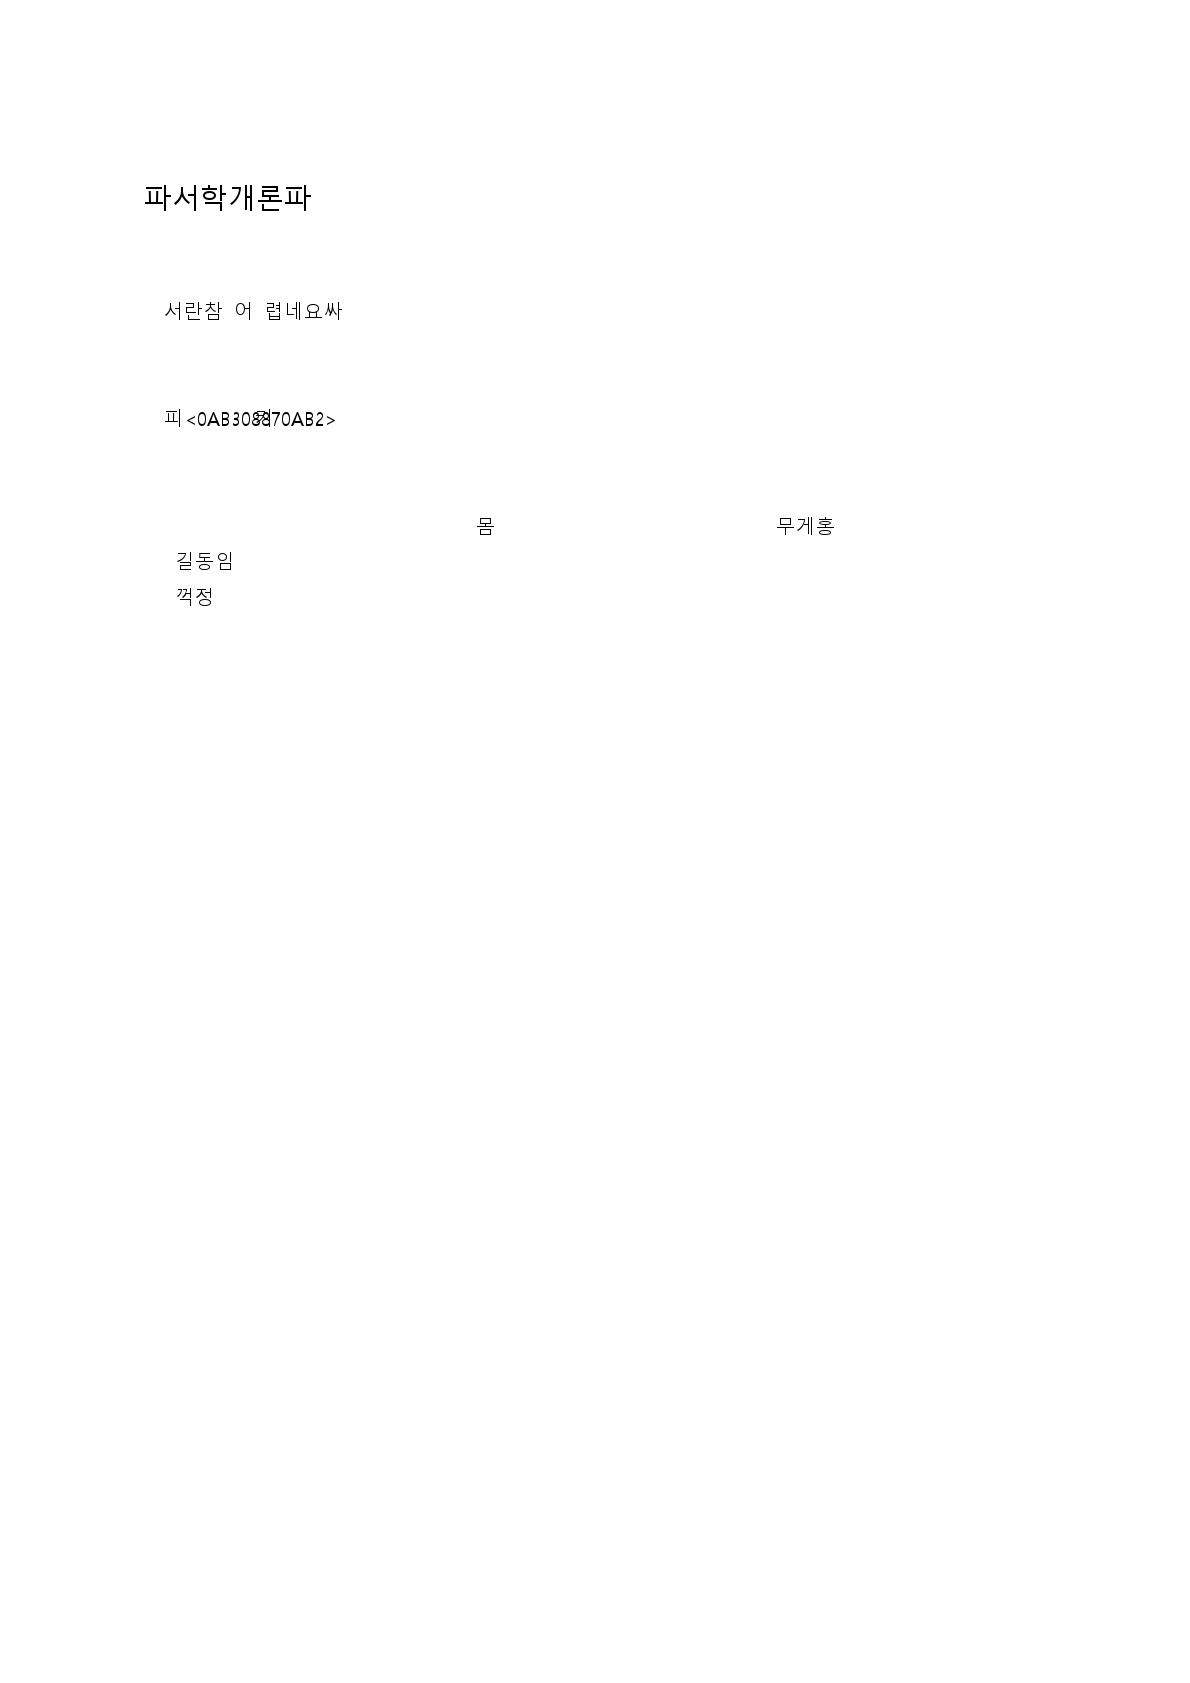

In [114]:
import re
from PIL import Image, ImageDraw, ImageFont


content_stream = r"""
 /P <</MCID 0>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 72.024 738.82 Tm
/GS10 gs
0 g
/GS11 gs
0 G
[<0AB3>] TJ
ET
Q
 EMC  /P <</MCID 1>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 86.064 738.82 Tm
0 g
0 G
[<06F0>] TJ
ET
Q
 EMC  /P <</MCID 2>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 100.1 738.82 Tm
0 g
0 G
[<0B1D>] TJ
ET
Q
 EMC  /P <</MCID 3>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 114.14 738.82 Tm
0 g
0 G
[<028E>] TJ
ET
Q
 EMC  /P <</MCID 4>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 14.04 Tf
1 0 0 1 128.06 738.82 Tm
0 g
0 G
[<053D>] TJ
ET
Q
 EMC  /Span <</MCID 5/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 14.04 Tf
1 0 0 1 141.98 738.82 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /Span <</MCID 6/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 72.024 709.9 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /P <</MCID 7>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 72.024 683.26 Tm
0 g
0 G
[<0AB3>] TJ
ET
Q
 EMC  /P <</MCID 8>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 81.984 683.26 Tm
0 g
0 G
[<06F0>] TJ
ET
Q
 EMC  /P <</MCID 9>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 91.944 683.26 Tm
0 g
0 G
[<0504>] TJ
ET
Q
 EMC  /Span <</MCID 10/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 102.02 683.26 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /P <</MCID 11>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 106.94 683.26 Tm
0 g
0 G
[<0973>] TJ
ET
Q
 EMC  /Span <</MCID 12/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 117.02 683.26 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /P <</MCID 13>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 121.94 683.26 Tm
0 g
0 G
[<07ED>] TJ
ET
Q
 EMC  /P <</MCID 14>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 131.9 683.26 Tm
0 g
0 G
[<0533>] TJ
ET
Q
 EMC  /P <</MCID 15>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 141.98 683.26 Tm
0 g
0 G
[<03CC>] TJ
ET
Q
 EMC  /P <</MCID 16>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 151.94 683.26 Tm
0 g
0 G
[<0841>] TJ
ET
Q
 EMC  /Span <</MCID 17/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 161.9 683.26 Tm
0 g
0 G
[(.)] TJ
ET
Q
 EMC  /Span <</MCID 18/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 164.18 683.26 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /Span <</MCID 19/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 72.024 656.5 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /P <</MCID 20>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 72.024 629.86 Tm
0 g
0 G
[<076F>] TJ
ET
Q
 EMC  /P <</MCID 21>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 81.984 629.86 Tm
0 g
0 G
[<0B14>] TJ
ET
Q
 EMC  /Span <</MCID 22/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 91.944 629.86 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /P <</MCID 23>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 96.984 629.86 Tm
0 g
0 G
[<0AB308870AB2>] TJ
ET
Q
 EMC  /Span <</MCID 24/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 126.98 629.86 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC  /Span <</MCID 25/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 72.024 603.22 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC q
72.504 571.63 149.78 17.304 re
W* n
 /Span <</MCID 26/Lang (en-US)>> BDC q
72.504 571.63 149.78 17.304 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 77.664 576.07 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC Q
q
222.77 571.63 149.78 17.304 re
W* n
 /P <</MCID 27>> BDC q
222.77 571.63 149.78 17.304 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 227.93 576.07 Tm
0 g
0 G
[<0A41>] TJ
ET
Q
 EMC  /Span <</MCID 28/Lang (en-US)>> BDC q
222.77 571.63 149.78 17.304 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 237.89 576.07 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC Q
q
373.03 571.63 149.9 17.304 re
W* n
 /P <</MCID 29>> BDC q
373.03 571.63 149.9 17.304 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 378.19 576.07 Tm
0 g
0 G
[<05C1>] TJ
ET
Q
 EMC  /P <</MCID 30>> BDC q
373.03 571.63 149.9 17.304 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 388.15 576.07 Tm
0 g
0 G
[<05D4>] TJ
ET
Q
 EMC  /P <</MCID 31>> BDC q
373.03 571.63 149.9 17.304 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 398.11 576.07 Tm
0 g
0 G
[<02AF>] TJ
ET
Q
 EMC  /Span <</MCID 32/Lang (en-US)>> BDC q
373.03 571.63 149.9 17.304 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 408.19 576.07 Tm
0 g
0 G
[( )] TJ
ET
Q
 EMC Q
/Artifact BMC 0 g
72.024 588.94 0.48 0.48001 re
f*
72.024 588.94 0.48 0.48001 re
f*
72.504 588.94 149.78 0.48001 re
f*
222.29 588.94 0.48001 0.48001 re
f*
222.77 588.94 149.78 0.48001 re
f*
372.55 588.94 0.48001 0.48001 re
f*
373.03 588.94 149.9 0.48001 re
f*
522.94 588.94 0.48004 0.48001 re
f*
522.94 588.94 0.48004 0.48001 re
f*
72.024 571.63 0.48 17.304 re
f*
222.29 571.63 0.48001 17.304 re
f*
372.55 571.63 0.48001 17.304 re
f*
522.94 571.63 0.48004 17.304 re
f*
 EMC q
72.504 553.75 149.78 17.28 re
W* n
 /P <</MCID 33>> BDC q
72.504 553.75 149.78 17.28 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 77.664 558.19 Tm
0 G
[<0B56>] TJ
ET
Q
 EMC  /P <</MCID 34>> BDC q
72.504 553.75 149.78 17.28 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 87.624 558.19 Tm
0 G
[<031F>] TJ
ET
Q
 EMC  /P <</MCID 35>> BDC q
72.504 553.75 149.78 17.28 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 97.584 558.19 Tm
0 G
[<0470>] TJ
ET
Q
 EMC  /Span <</MCID 36/Lang (en-US)>> BDC q
72.504 553.75 149.78 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 107.66 558.19 Tm
0 G
[( )] TJ
ET
Q
 EMC Q
q
222.77 553.75 149.78 17.28 re
W* n
 /Span <</MCID 37/Lang (en-US)>> BDC q
222.77 553.75 149.78 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 227.93 558.19 Tm
0 G
[(1)] TJ
ET
Q
 EMC  /Span <</MCID 38/Lang (en-US)>> BDC q
222.77 553.75 149.78 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 233.45 558.19 Tm
0 G
[(7)] TJ
ET
Q
 EMC  /Span <</MCID 39/Lang (en-US)>> BDC q
222.77 553.75 149.78 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 238.97 558.19 Tm
0 G
[(5)] TJ
ET
Q
 EMC  /Span <</MCID 40/Lang (en-US)>> BDC q
222.77 553.75 149.78 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 244.49 558.19 Tm
0 G
[( )] TJ
ET
Q
 EMC Q
q
373.03 553.75 149.9 17.28 re
W* n
 /Span <</MCID 41/Lang (en-US)>> BDC q
373.03 553.75 149.9 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 378.19 558.19 Tm
0 G
[(7)] TJ
ET
Q
 EMC  /Span <</MCID 42/Lang (en-US)>> BDC q
373.03 553.75 149.9 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 383.71 558.19 Tm
0 G
[(0)] TJ
ET
Q
 EMC  /Span <</MCID 43/Lang (en-US)>> BDC q
373.03 553.75 149.9 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 389.23 558.19 Tm
0 G
[( )] TJ
ET
Q
 EMC Q
/Artifact BMC 72.024 571.15 0.48 0.48001 re
f*
72.504 571.15 149.78 0.48001 re
f*
222.29 571.15 0.48001 0.48001 re
f*
222.77 571.15 149.78 0.48001 re
f*
372.55 571.15 0.48001 0.48001 re
f*
373.03 571.15 149.9 0.48001 re
f*
522.94 571.15 0.48004 0.48001 re
f*
72.024 553.75 0.48 17.4 re
f*
222.29 553.75 0.48001 17.4 re
f*
372.55 553.75 0.48001 17.4 re
f*
522.94 553.75 0.48004 17.4 re
f*
 EMC q
72.504 535.99 149.78 17.28 re
W* n
 /P <</MCID 44>> BDC q
72.504 535.99 149.78 17.28 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 77.664 540.43 Tm
0 G
[<088E>] TJ
ET
Q
 EMC  /P <</MCID 45>> BDC q
72.504 535.99 149.78 17.28 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 87.624 540.43 Tm
0 G
[<0340>] TJ
ET
Q
 EMC  /P <</MCID 46>> BDC q
72.504 535.99 149.78 17.28 re
W* n
BT
/F1 9.96 Tf
1 0 0 1 97.584 540.43 Tm
0 G
[<08BD>] TJ
ET
Q
 EMC  /Span <</MCID 47/Lang (en-US)>> BDC q
72.504 535.99 149.78 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 107.66 540.43 Tm
0 G
[( )] TJ
ET
Q
 EMC Q
q
222.77 535.99 149.78 17.28 re
W* n
 /Span <</MCID 48/Lang (en-US)>> BDC q
222.77 535.99 149.78 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 227.93 540.43 Tm
0 G
[(1)] TJ
ET
Q
 EMC  /Span <</MCID 49/Lang (en-US)>> BDC q
222.77 535.99 149.78 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 233.45 540.43 Tm
0 G
 0.032 Tc[(80)] TJ
ET
Q
 EMC  /Span <</MCID 50/Lang (en-US)>> BDC q
222.77 535.99 149.78 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 244.49 540.43 Tm
0 G
[( )] TJ
ET
Q
 EMC Q
q
373.03 535.99 149.9 17.28 re
W* n
 /Span <</MCID 51/Lang (en-US)>> BDC q
373.03 535.99 149.9 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 378.19 540.43 Tm
0 G
[(1)] TJ
ET
Q
 EMC  /Span <</MCID 52/Lang (en-US)>> BDC q
373.03 535.99 149.9 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 383.71 540.43 Tm
0 G
 0.032 Tc[(00)] TJ
ET
Q
 EMC  /Span <</MCID 53/Lang (en-US)>> BDC q
373.03 535.99 149.9 17.28 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 394.75 540.43 Tm
0 G
[( )] TJ
ET
Q
 EMC Q
/Artifact BMC 72.024 553.27 0.48 0.48001 re
f*
72.504 553.27 149.78 0.48001 re
f*
222.29 553.27 0.48001 0.48001 re
f*
222.77 553.27 149.78 0.48001 re
f*
372.55 553.27 0.48001 0.48001 re
f*
373.03 553.27 149.9 0.48001 re
f*
522.94 553.27 0.48004 0.48001 re
f*
72.024 535.99 0.48 17.28 re
f*
72.024 535.51 0.48 0.47998 re
f*
72.024 535.51 0.48 0.47998 re
f*
72.504 535.51 149.78 0.47998 re
f*
222.29 535.99 0.48001 17.28 re
f*
222.29 535.51 0.48001 0.47998 re
f*
222.77 535.51 149.78 0.47998 re
f*
372.55 535.99 0.48001 17.28 re
f*
372.55 535.51 0.48001 0.47998 re
f*
373.03 535.51 149.9 0.47998 re
f*
522.94 535.99 0.48004 17.28 re
f*
522.94 535.51 0.48004 0.47998 re
f*
522.94 535.51 0.48004 0.47998 re
f*
 EMC  /Span <</MCID 54/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 72.024 522.67 Tm
0 G
[( )] TJ
ET
Q
 EMC  /Span <</MCID 55/Lang (en-US)>> BDC q
0.000008871 0 595.32 841.92 re
W* n
BT
/F2 9.96 Tf
1 0 0 1 72.024 496.03 Tm
0 G
[( )] TJ
ET
Q
 EMC 
"""
# r"""
#  /P <</MCID 0>> BDC q
# 0.000008871 0 595.32 841.92 re
# W* n
# BT
# /F1 14.04 Tf
# 1 0 0 1 72.024 738.82 Tm
# /GS10 gs
# 0 g
# /GS11 gs
# 0 G
# [<0AB3>] TJ
# ET
# Q
#  EMC  /P <</MCID 1>> BDC q
# 0.000008871 0 595.32 841.92 re
# W* n
# BT
# /F1 14.04 Tf
# 1 0 0 1 86.064 738.82 Tm
# 0 g
# 0 G
# [<06F0>] TJ
# ET
# Q
#  EMC
# """


tounicode_cmap = r"""
/CIDInit /ProcSet findresource begin
12 dict begin
begincmap
/CIDSystemInfo
<< /Registry (Adobe)
/Ordering (UCS)
/Supplement 0
>> def
/CMapName /Adobe-Identity-UCS def
/CMapType 2 def
1 begincodespacerange
<0000> <FFFF>
endcodespacerange
20 beginbfchar
<028E> <AC1C>
<02AF> <AC8C>
<031F> <AE38>
<0340> <AEBD>
<03CC> <B124>
<0470> <B3D9>
<0504> <B780>
<0533> <B835>
<053D> <B860>
<05C1> <BAB8>
<05D4> <BB34>
<06F0> <C11C>
<076F> <C2F8>
<07ED> <C5B4>
<0841> <C694>
<0887> <C774>
<088E> <C784>
<08BD> <C815>
<0973> <CC38>
<0A41> <D0A4>
endbfchar
1 beginbfrange
<0AB2> <0AB3> [<D305> <D30C>]
endbfrange
3 beginbfchar
<0B14> <D53C>
<0B1D> <D559>
<0B56> <D64D>
endbfchar
endcmap
CMapName currentdict /CMap defineresource pop
end
end
"""


def decode_utf16be_hex(hex_string: str) -> str:
    return bytes.fromhex(hex_string).decode("utf-16-be", errors="replace")


def parse_tounicode_cmap(cmap_text: str) -> dict[str, str]:
    mapping = {}

    # beginbfchar ... endbfchar
    for block in re.findall(r"beginbfchar(.*?)endbfchar", cmap_text, flags=re.DOTALL):
        pairs = re.findall(r"<([0-9A-Fa-f]+)>\s+<([0-9A-Fa-f]+)>", block)
        for src, dst in pairs:
            mapping[src.upper()] = decode_utf16be_hex(dst)

    # beginbfrange ... endbfrange
    for block in re.findall(r"beginbfrange(.*?)endbfrange", cmap_text, flags=re.DOTALL):
        # 예: <0AB2> <0AB3> [<D305> <D30C>]
        array_ranges = re.findall(
            r"<([0-9A-Fa-f]+)>\s+<([0-9A-Fa-f]+)>\s+\[(.*?)\]",
            block,
            flags=re.DOTALL,
        )

        for start, end, arr in array_ranges:
            start_i = int(start, 16)
            dst_values = re.findall(r"<([0-9A-Fa-f]+)>", arr)
            width = len(start)

            for offset, dst in enumerate(dst_values):
                src = f"{start_i + offset:0{width}X}"
                mapping[src] = decode_utf16be_hex(dst)

        # 예: <0001> <0003> <AC00>
        sequential_ranges = re.findall(
            r"<([0-9A-Fa-f]+)>\s+<([0-9A-Fa-f]+)>\s+<([0-9A-Fa-f]+)>",
            block,
        )

        for start, end, dst_start in sequential_ranges:
            start_i = int(start, 16)
            end_i = int(end, 16)
            dst_i = int(dst_start, 16)
            width = len(start)

            for offset, src_i in enumerate(range(start_i, end_i + 1)):
                src = f"{src_i:0{width}X}"
                mapping[src] = chr(dst_i + offset)

    return mapping


def parse_text_draw_events(stream_text: str):
    """
    지금 공유하신 패턴에 맞춘 단순 파서입니다.

    추출 대상:
    /F1 14.04 Tf
    1 0 0 1 x y Tm
    [<HEX>] TJ
    """
    pattern = re.compile(
        r"""
        /(?P<font>F\d+)\s+
        (?P<size>[-+]?\d+(?:\.\d+)?)\s+Tf
        .*?
        1\s+0\s+0\s+1\s+
        (?P<x>[-+]?\d+(?:\.\d+)?)\s+
        (?P<y>[-+]?\d+(?:\.\d+)?)\s+Tm
        .*?
        \[\s*<(?P<hex>[0-9A-Fa-f]+)>\s*\]\s*TJ
        """,
        re.VERBOSE | re.DOTALL,
    )

    events = []

    for m in pattern.finditer(stream_text):
        events.append({
            "font": "/" + m.group("font"),
            "size": float(m.group("size")),
            "x": float(m.group("x")),
            "y": float(m.group("y")),
            "hex": m.group("hex").upper(),
        })

    return events


def pdf_point_to_image_xy(x_pt: float, y_pt: float, page_height_pt: float, scale: float):
    """
    PDF 좌표계:
      원점이 왼쪽 아래.

    PIL 이미지 좌표계:
      원점이 왼쪽 위.

    따라서 y축을 뒤집어야 합니다.
    """
    x = x_pt * scale
    y = (page_height_pt - y_pt) * scale
    return x, y


def render_text_events_to_image(events, to_unicode, output_path="rendered.png"):
    page_width_pt = 595.32
    page_height_pt = 841.92

    # 72pt = 1inch 기준.
    # scale=2면 대략 144dpi 이미지가 됩니다.
    scale = 2.0

    img_width = int(page_width_pt * scale)
    img_height = int(page_height_pt * scale)

    image = Image.new("RGB", (img_width, img_height), "white")
    draw = ImageDraw.Draw(image)

    # 시스템에 맞게 폰트 경로를 바꾸세요.
    # Windows:
    # font_path = r"C:\Windows\Fonts\malgun.ttf"
    #
    # macOS 또는 Linux에서는 NotoSansCJK 같은 폰트를 지정하세요.
    font_path = r"C:\Windows\Fonts\malgun.ttf"

    font_cache = {}

    for event in events:
        hex_code = event["hex"]
        text = to_unicode.get(hex_code, f"<{hex_code}>")

        font_size_px = int(event["size"] * scale)

        if font_size_px not in font_cache:
            font_cache[font_size_px] = ImageFont.truetype(font_path, font_size_px)

        font = font_cache[font_size_px]

        x, y = pdf_point_to_image_xy(
            event["x"],
            event["y"],
            page_height_pt,
            scale,
        )

        # PDF의 Tm y는 보통 텍스트 baseline 기준입니다.
        # PIL의 text y는 글자 박스 상단 기준이라 약간 위로 보정합니다.
        y_adjusted = y - font_size_px

        draw.text((x, y_adjusted), text, font=font, fill="black")

    # image.save(output_path)
    return image


to_unicode = parse_tounicode_cmap(tounicode_cmap)
events = parse_text_draw_events(content_stream)

for event in events:
    event["text"] = to_unicode.get(event["hex"], f"<{event['hex']}>")
    print(event)

render_text_events_to_image(events, to_unicode, "rendered.png")